# Data Pre-Processing

In [1]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit

In [2]:
# 2. Load dữ liệu
# Lưu ý: File BBox cột tên ảnh thường là 'Image Index', cột nhãn là 'Finding Label'
bbox_df = pd.read_csv('/kaggle/input/data/BBox_List_2017.csv')
entry_df = pd.read_csv('/kaggle/input/data01/Data_Entry_2017_v2020.csv')

In [3]:
bbox_df.head()

,Image Index,Finding Label,Bbox [x,y,w,h],Unnamed: 6,Unnamed: 7,Unnamed: 8
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,NaN,NaN,NaN
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,NaN,NaN,NaN
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,NaN,NaN,NaN
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,NaN,NaN,NaN
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,NaN,NaN,NaN


In [4]:
entry_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168


In [5]:
bbox_df.keys()

Index(['Image Index', 'Finding Label', 'Bbox [x', 'y', 'w', 'h]', 'Unnamed: 6',
       'Unnamed: 7', 'Unnamed: 8'],
      dtype='object')

In [6]:
entry_df.keys()

Index(['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID',
       'Patient Age', 'Patient Sex', 'View Position', 'OriginalImage[Width',
       'Height]', 'OriginalImagePixelSpacing[x', 'y]'],
      dtype='object')

In [7]:
bbox_df.shape

(984, 9)

In [8]:
entry_df.shape

(112120, 11)

In [9]:
bbox_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Image Index    984 non-null    object 
 1   Finding Label  984 non-null    object 
 2   Bbox [x        984 non-null    float64
 3   y              984 non-null    float64
 4   w              984 non-null    float64
 5   h]             984 non-null    float64
 6   Unnamed: 6     0 non-null      float64
 7   Unnamed: 7     0 non-null      float64
 8   Unnamed: 8     0 non-null      float64
dtypes: float64(7), object(2)
memory usage: 69.3+ KB


In [10]:
entry_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Sex                  112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
dtypes: float64(2), int64(5), object(4)
memory usage: 9.4+ MB


In [11]:
bbox_df = bbox_df.rename(columns={
    'Bbox [x': 'x', 
    'y': 'y', 
    'w': 'w', 
    'h]': 'h',
    'Finding Label': 'Finding Label' 
})

In [12]:
entry_subset = entry_df[['Image Index', 'Patient ID', 'OriginalImagePixelSpacing[x', 'y]']]

In [13]:
merged_df = pd.merge(bbox_df, entry_subset, on='Image Index', how='inner')

In [14]:
print(f"Tổng số lượng ảnh ban đầu: {len(merged_df)}")
print("Các loại bệnh bao gồm:", merged_df['Finding Label'].unique())

Tổng số lượng ảnh ban đầu: 984
Các loại bệnh bao gồm: ['Atelectasis' 'Cardiomegaly' 'Effusion' 'Infiltrate' 'Mass' 'Nodule'
 'Pneumonia' 'Pneumothorax']


/tmp/ipykernel_55/3993659270.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Finding Label', data=bbox_df, order=bbox_df['Finding Label'].value_counts().index, palette='viridis')


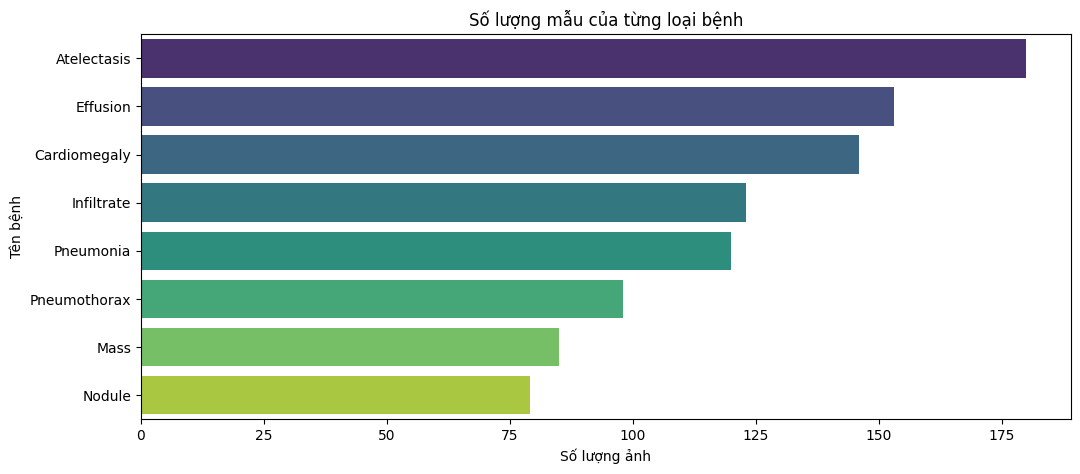

In [15]:
plt.figure(figsize=(12, 5))
sns.countplot(y='Finding Label', data=bbox_df, order=bbox_df['Finding Label'].value_counts().index, palette='viridis')
plt.title('Số lượng mẫu của từng loại bệnh')
plt.xlabel('Số lượng ảnh')
plt.ylabel('Tên bệnh')
plt.show()

In [16]:
# - Mass, Nodule:
# - Pneumonia (Viêm phổi), Infiltrate (Thâm nhiễm):
target_diseases = ['Mass', 'Nodule', 'Pneumonia', 'Infiltrate']
viz_df = merged_df[merged_df['Finding Label'].isin(target_diseases)].copy()

# 3. Tính tỷ lệ khung hình (Aspect Ratio = w / h)
# Nếu là hình tròn/vuông (khối u chuẩn) thì tỷ lệ này xoay quanh 1.0
viz_df['Aspect_Ratio'] = viz_df['w'] / viz_df['h']

print(f"Số lượng mẫu dùng để so sánh: {len(viz_df)}")

Số lượng mẫu dùng để so sánh: 407


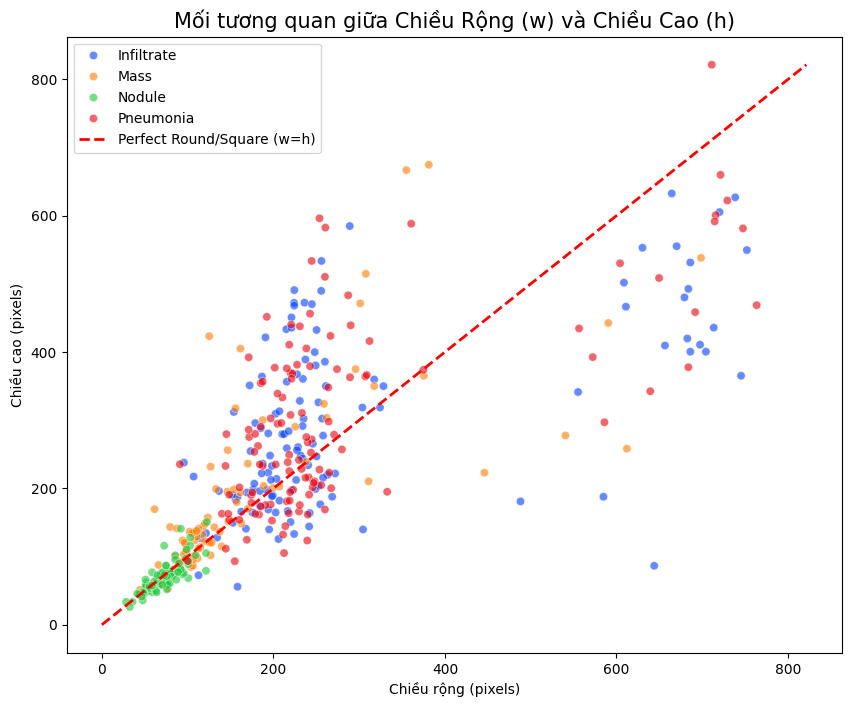

In [17]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=viz_df, x='w', y='h', hue='Finding Label', alpha=0.6, palette='bright')

# Vẽ đường chéo y = x (Tỷ lệ vàng của hình tròn/vuông)
max_val = max(viz_df['w'].max(), viz_df['h'].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Round/Square (w=h)')

plt.title('Mối tương quan giữa Chiều Rộng (w) và Chiều Cao (h)', fontsize=15)
plt.xlabel('Chiều rộng (pixels)')
plt.ylabel('Chiều cao (pixels)')
plt.legend()
plt.show()

In [18]:
target_diseases = ['Mass', 'Nodule']
clean_df = merged_df[merged_df['Finding Label'].isin(target_diseases)].copy()

In [19]:
# --- BƯỚC 3: TÌM ĐƯỜNG DẪN ẢNH (PATH) ---
print("Đang quét file ảnh...")
all_image_paths = {os.path.basename(x): x for x in glob('/kaggle/input/**/*.png', recursive=True)}

clean_df['path'] = clean_df['Image Index'].map(all_image_paths)
clean_df = clean_df.dropna(subset=['path']) # Bỏ dòng nào ko tìm thấy ảnh

Đang quét file ảnh...


In [20]:
# 2. Loại bỏ dữ liệu lỗi (Kích thước <= 0)
invalid_rows = clean_df[
    (clean_df['w'] <= 0) | 
    (clean_df['h'] <= 0) | 
    (clean_df['x'] < 0) | 
    (clean_df['y'] < 0)
]

if len(invalid_rows) > 0:
    print(f"Đã loại bỏ {len(invalid_rows)} dòng lỗi tọa độ.")
    clean_df = clean_df.drop(invalid_rows.index)

/tmp/ipykernel_55/1635754846.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_df, x='Finding Label', y='Aspect_Ratio', palette='Set2', showfliers=False)


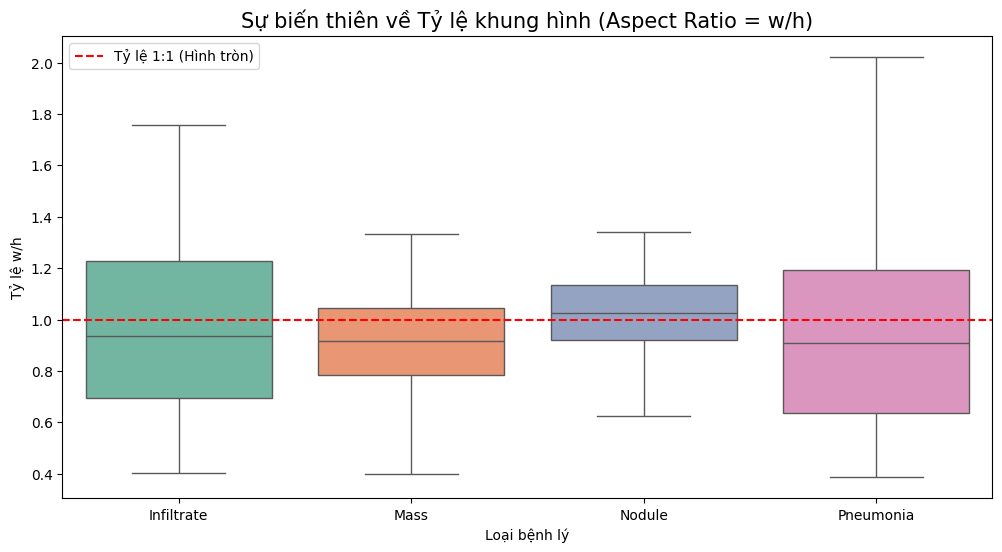

In [21]:
plt.figure(figsize=(12, 6))

# Vẽ Boxplot
sns.boxplot(data=viz_df, x='Finding Label', y='Aspect_Ratio', palette='Set2', showfliers=False)

# Vẽ đường tỷ lệ 1.0
plt.axhline(y=1.0, color='r', linestyle='--', label='Tỷ lệ 1:1 (Hình tròn)')

plt.title('Sự biến thiên về Tỷ lệ khung hình (Aspect Ratio = w/h)', fontsize=15)
plt.ylabel('Tỷ lệ w/h')
plt.xlabel('Loại bệnh lý')
plt.legend()
plt.show()

In [22]:
# 1. Kiểm tra giá trị Null
print("Kiểm tra Null:\n", clean_df[['x', 'y', 'w', 'h']].isnull().sum())

Kiểm tra Null:
 x    0
y    0
w    0
h    0
dtype: int64


In [23]:
# 3. Kiểm tra kích thước bbox có vượt quá ảnh không (Ảnh gốc NIH là 1024x1024)
out_of_bound = clean_df[(clean_df['x'] + clean_df['w'] > 1024) | (clean_df['y'] + clean_df['h'] > 1024)]
print(f"Số lượng bbox vượt quá kích thước ảnh 1024x1024: {len(out_of_bound)}")

Số lượng bbox vượt quá kích thước ảnh 1024x1024: 0


In [24]:
def convert_pixels_to_mm(df):
    df = df.copy()
    
    # Lấy thông tin Spacing (Nếu ko có cột này thì dùng chuẩn 0.143)
    if 'OriginalImagePixelSpacing[x' in df.columns:
        spacing_x = df['OriginalImagePixelSpacing[x']
        spacing_y = df['y]']
    else:
        spacing_x = 0.143
        spacing_y = 0.143
        
    # Tính toán
    df['w_mm'] = df['w'] * spacing_x
    df['h_mm'] = df['h'] * spacing_y
    
    # Kích thước khối u = Cạnh lớn nhất (Max Diameter)
    df['Tumor_Size_mm'] = df[['w_mm', 'h_mm']].max(axis=1)
    
    return df

clean_df = convert_pixels_to_mm(clean_df)

In [25]:
# --- BƯỚC 5: CHIA TẬP TRAIN/VAL/TEST (Theo Patient ID) ---
print("Đang chia tập dữ liệu...")

# Tách Train (70%) và Temp (30%)
splitter_1 = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=42)
train_idxs, temp_idxs = next(splitter_1.split(clean_df, groups=clean_df['Patient ID']))

train_df = clean_df.iloc[train_idxs].copy()
temp_df = clean_df.iloc[temp_idxs].copy()

# Tách Temp thành Val (15%) và Test (15%)
splitter_2 = GroupShuffleSplit(test_size=0.50, n_splits=1, random_state=42)
val_idxs, test_idxs = next(splitter_2.split(temp_df, groups=temp_df['Patient ID']))

val_df = temp_df.iloc[val_idxs].copy()
test_df = temp_df.iloc[test_idxs].copy()

# --- BƯỚC 6: LƯU FILE ---
cols_to_keep = [
    'Image Index', 'Patient ID', 'Finding Label', 
    'path', 'Tumor_Size_mm', # Quan trọng nhất
    'x', 'y', 'w', 'h',      # Để tham khảo nếu cần
    'w_mm', 'h_mm'
]

# Lọc cột
train_df = train_df[cols_to_keep]
val_df = val_df[cols_to_keep]
test_df = test_df[cols_to_keep]

# Xuất file
output_dir = '/kaggle/working/'
train_df.to_csv(os.path.join(output_dir, 'train.csv'), index=False)
val_df.to_csv(os.path.join(output_dir, 'val.csv'), index=False)
test_df.to_csv(os.path.join(output_dir, 'test.csv'), index=False)

print("-" * 30)
print(f"Tổng số ảnh sạch: {len(clean_df)}")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Đã lưu file csv chuẩn vào: {output_dir}")
print("-" * 30)
train_df.head()

Đang chia tập dữ liệu...
------------------------------
Tổng số ảnh sạch: 164
Train: 115 | Val: 26 | Test: 23
Đã lưu file csv chuẩn vào: /kaggle/working/
------------------------------


,Image Index,Patient ID,Finding Label,path,Tumor_Size_mm,x,y,w,h,w_mm,h_mm
583,00023075_033.png,23075,Mass,/kaggle/input/data/images_010/images/00023075_...,10.412942,239.502222,535.077934,72.817778,65.991111,10.412942,9.436729
584,00029579_005.png,29579,Mass,/kaggle/input/data/images_012/images/00029579_...,14.370378,609.280000,189.193490,73.955556,71.680000,14.370378,13.928212
585,00013659_019.png,13659,Mass,/kaggle/input/data/images_006/images/00013659_...,22.937600,559.217778,167.575712,102.400000,136.533333,17.203200,22.937600
586,00010815_006.png,10815,Mass,/kaggle/input/data/images_005/images/00010815_...,36.608000,311.182222,241.531267,146.773333,256.000000,20.988587,36.608000
587,00026695_000.png,26695,Mass,/kaggle/input/data/images_011/images/00026695_...,18.873458,341.902222,197.157934,117.191111,131.982222,16.758329,18.873458


# EDA

In [26]:
import matplotlib.patches as patches
from PIL import Image
import ast
import seaborn as sns

In [27]:
train_df = pd.read_csv('/kaggle/working/train.csv')

In [28]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

count    115.000000
mean      24.042872
std       23.351679
min        4.803589
25%       11.668074
50%       16.115268
75%       23.729246
max      129.554484
Name: Tumor_Size_mm, dtype: float64


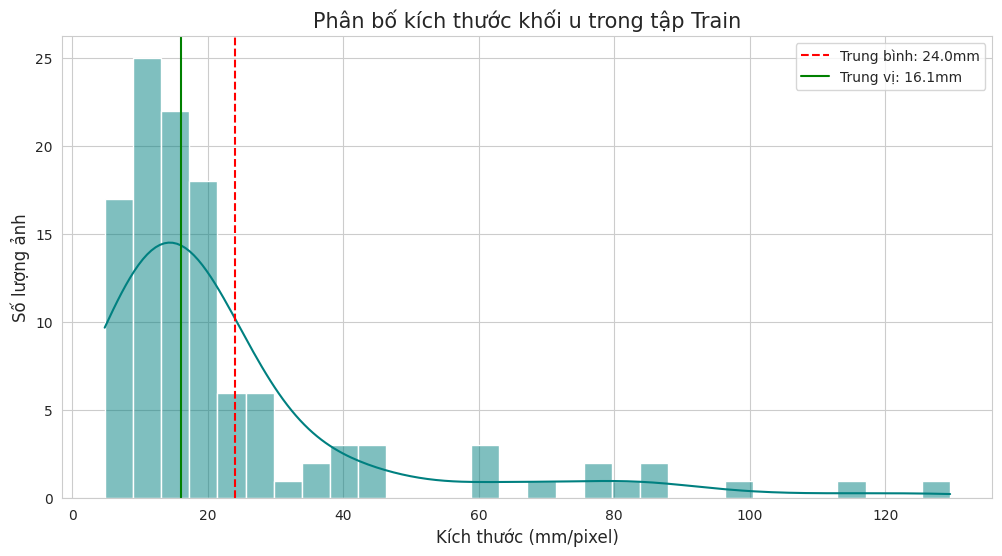

Kích thước nhỏ nhất: 4.80
Kích thước lớn nhất: 129.55
Kích thước trung bình: 24.04
Độ lệch chuẩn (Std): 23.35


In [29]:
# Vẽ biểu đồ phân bố kích thước
sns.histplot(train_df['Tumor_Size_mm'], kde=True, bins=30, color='teal')

# Thêm các đường chỉ thị thống kê
mean_val = train_df['Tumor_Size_mm'].mean()
median_val = train_df['Tumor_Size_mm'].median()
# In thống kê cơ bản
print(train_df['Tumor_Size_mm'].describe())

plt.axvline(mean_val, color='r', linestyle='--', label=f'Trung bình: {mean_val:.1f}mm')
plt.axvline(median_val, color='g', linestyle='-', label=f'Trung vị: {median_val:.1f}mm')

plt.title('Phân bố kích thước khối u trong tập Train', fontsize=15)
plt.xlabel('Kích thước (mm/pixel)', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)
plt.legend()
plt.show()

# In ra số liệu để bạn copy vào báo cáo
print(f"Kích thước nhỏ nhất: {train_df['Tumor_Size_mm'].min():.2f}")
print(f"Kích thước lớn nhất: {train_df['Tumor_Size_mm'].max():.2f}")
print(f"Kích thước trung bình: {mean_val:.2f}")
print(f"Độ lệch chuẩn (Std): {train_df['Tumor_Size_mm'].std():.2f}")

/tmp/ipykernel_55/4212570744.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Finding Label', y='Tumor_Size_mm', data=train_df, palette="Set2")


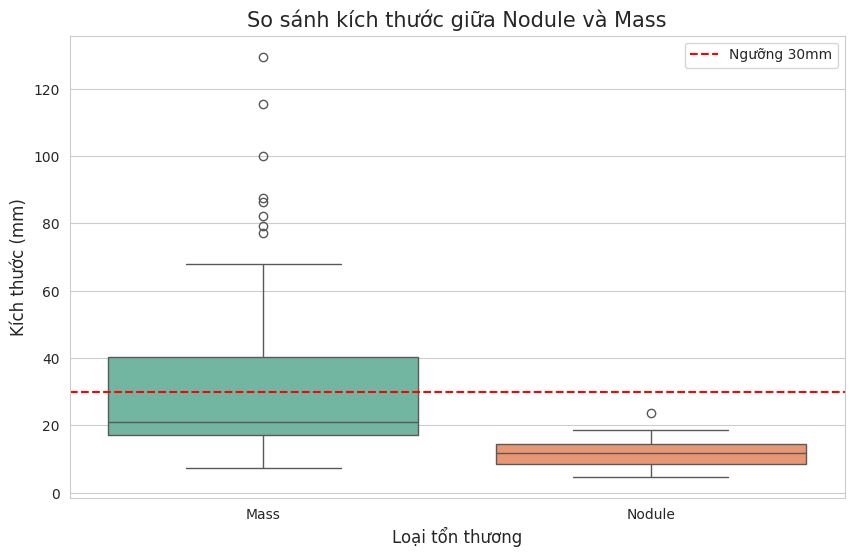

In [30]:
plt.figure(figsize=(10, 6))

# Vẽ Boxplot so sánh
sns.boxplot(x='Finding Label', y='Tumor_Size_mm', data=train_df, palette="Set2")

plt.title('So sánh kích thước giữa Nodule và Mass', fontsize=15)
plt.xlabel('Loại tổn thương', fontsize=12)
plt.ylabel('Kích thước (mm)', fontsize=12)

plt.axhline(y=30, color='r', linestyle='--', label='Ngưỡng 30mm')
plt.legend()
plt.show()

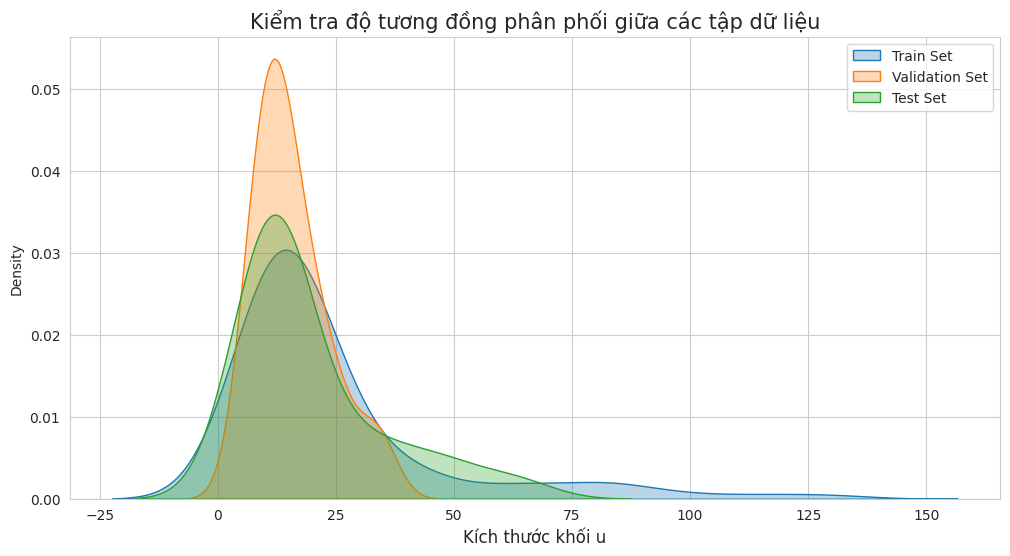

In [31]:
plt.figure(figsize=(12, 6))

# Vẽ 3 đường phân phối chồng lên nhau
sns.kdeplot(train_df['Tumor_Size_mm'], label='Train Set', fill=True, alpha=0.3)
sns.kdeplot(val_df['Tumor_Size_mm'], label='Validation Set', fill=True, alpha=0.3)
sns.kdeplot(test_df['Tumor_Size_mm'], label='Test Set', fill=True, alpha=0.3)

plt.title('Kiểm tra độ tương đồng phân phối giữa các tập dữ liệu', fontsize=15)
plt.xlabel('Kích thước khối u', fontsize=12)
plt.legend()
plt.show()

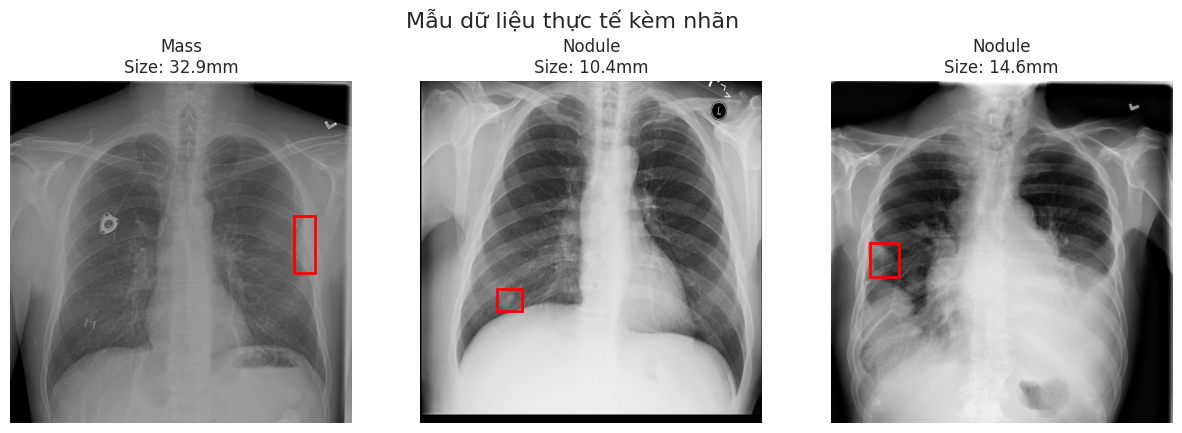

In [32]:
import matplotlib.patches as patches
import random

def visualize_samples(df, num_samples=3):
    plt.figure(figsize=(15, 5))
    
    # Lấy ngẫu nhiên mẫu
    samples = df.sample(num_samples)
    
    for i, (idx, row) in enumerate(samples.iterrows()):
        ax = plt.subplot(1, num_samples, i+1)
        
        # Đọc ảnh
        img_path = row['path']
        try:
            img = Image.open(img_path).convert('RGB')
        except:
            continue
            
        ax.imshow(img, cmap='gray')
        
        # Vẽ khung chữ nhật (Bounding Box)
        # x, y là góc trên trái, w là rộng, h là cao
        rect = patches.Rectangle((row['x'], row['y']), row['w'], row['h'], 
                                 linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        
        ax.set_title(f"{row['Finding Label']}\nSize: {row['Tumor_Size_mm']:.1f}mm")
        ax.axis('off')
    
    plt.suptitle("Mẫu dữ liệu thực tế kèm nhãn", fontsize=16)
    plt.show()

# Gọi hàm
visualize_samples(train_df)

# Dataset, Dataloader

In [58]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

# CẤU HÌNH DATA AUGMENTATION

data_transforms = {
    'train': transforms.Compose([
        # 1. Resize về kích thước chuẩn (BẮT BUỘC)
        transforms.Resize((224, 224)),
        
        # 2. Horizontal Flip (An toàn tuyệt đối)
        transforms.RandomHorizontalFlip(p=0.5),
        
        # 3. Random Rotation (Tăng góc xoay lên để model học tốt hơn)
        # Xoay không làm thay đổi diện tích khối u
        transforms.RandomRotation(degrees=15),
        
        # 4. Dịch chuyển ảnh (Shift/Translate) - THAY THẾ CHO ZOOM
        # Dịch ảnh sang trái/phải/lên/xuống tối đa 10%. 
        # Khối u vẫn giữ nguyên kích thước, chỉ đổi vị trí.
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        
        # 5. Tăng cường nhiễu màu/sáng (Mạnh tay hơn)
        # Giúp model chống lại các ảnh chụp X-quang kém chất lượng
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
        
        # 6. Làm mờ ảnh (Gaussian Blur) - MỚI
        # Giúp model không bị "học vẹt" vào các nhiễu hạt (noise) sắc nét
        transforms.GaussianBlur(kernel_size=(3, 5), sigma=(0.1, 2.0)),
        
        # 7. Cuối cùng mới chuyển sang Tensor & Normalize
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
# Test dùng chung transform với Val
data_transforms['test'] = data_transforms['val']


# XÂY DỰNG DATASET

class ChestXrayDataset(Dataset):
    def __init__(self, source, transform=None):
        if isinstance(source, str):
            self.df = pd.read_csv(source)
        else:
            self.df = source
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['path']
        
        # Xử lý lỗi nếu không tìm thấy ảnh
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # Nếu lỗi, trả về ảnh đen hoặc skip
            image = Image.new('RGB', (224, 224))
            
        # XỬ LÝ NHÃN
        raw_label = float(row['Tumor_Size_mm'])
        
        
        scaled_label = raw_label
        
        label = torch.tensor(scaled_label, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

# KHỞI TẠO DATALOADER

BATCH_SIZE = 32 

# Tạo Dataset
train_dataset = ChestXrayDataset('/kaggle/working/train.csv', transform=data_transforms['train'])
val_dataset = ChestXrayDataset('/kaggle/working/val.csv', transform=data_transforms['val'])
test_dataset = ChestXrayDataset('/kaggle/working/test.csv', transform=data_transforms['test'])

# Tạo DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Đã khởi tạo DataLoader thành công!")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Số lượng batch trong tập Train: {len(train_loader)}")

Đã khởi tạo DataLoader thành công!
Batch Size: 32
Số lượng batch trong tập Train: 4


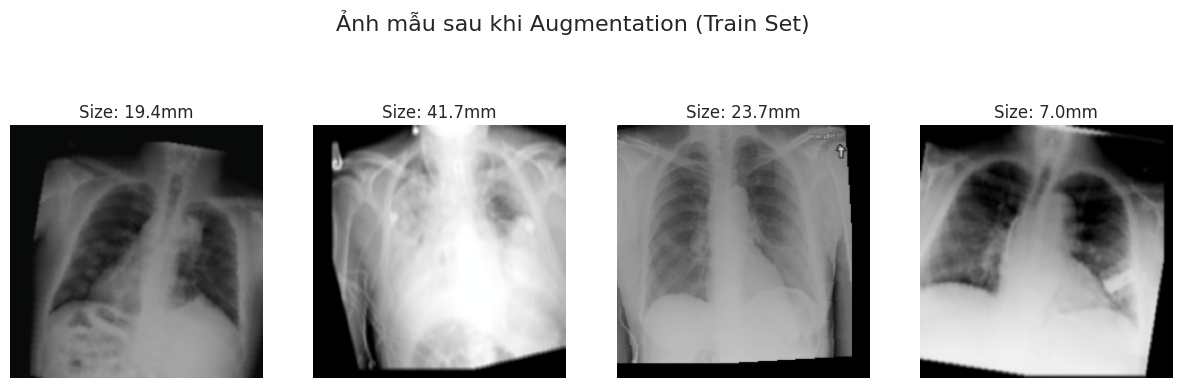

In [34]:
# Hàm visualize ảnh sau khi đã Normalize
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0)) # Chuyển từ (C, H, W) sang (H, W, C)
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    
    # Công thức ngược của Normalize: image = image * std + mean
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')

# Lấy 1 batch từ train_loader
inputs, classes = next(iter(train_loader))

# Vẽ 4 ảnh đầu tiên trong batch
plt.figure(figsize=(15, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    imshow(inputs[i], title=f"Size: {classes[i].item():.1f}mm")
plt.suptitle("Ảnh mẫu sau khi Augmentation (Train Set)", fontsize=16)
plt.show()

# Model

In [35]:
import torch.nn as nn
import torchvision.models as models

class TumorSizeResNet18(nn.Module):
    def __init__(self):
        super(TumorSizeResNet18, self).__init__()
        
        # Dùng ResNet18
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Bỏ 2 lớp cuối (AvgPool và FC)
        self.features = nn.Sequential(*list(backbone.children())[:-2])
        
        # 1. Freeze các lớp đầu (học đường nét cơ bản)
        for param in self.features.parameters():
            param.requires_grad = False
            
        # 2. Unfreeze Layer 4 (để học đặc trưng khối u)
        # Truy cập vào block layer4 của ResNet
        for param in self.features[7].parameters(): # layer4 nằm ở index 7 trong sequential
            param.requires_grad = True
            
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Regression Head
        # ResNet18 output 512 channels
        self.regression_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_avg_pool(x)
        output = self.regression_head(x)
        return output
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Khởi tạo
model = TumorSizeResNet18().to(device)

print(f"Đã khởi tạo Model ResNet18 thành công trên thiết bị: {device}")

# In sơ qua cấu trúc để kiểm tra (Optional)
print(model.regression_head)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s] 


Đã khởi tạo Model ResNet18 thành công trên thiết bị: cuda
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=512, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=256, out_features=1, bias=True)
)


In [36]:
print(model)

TumorSizeResNet18(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_

In [37]:
from torchsummary import summary

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [38]:
num_modules = len(list(model.modules()))
print(f"Tổng số lượng modules (lớp con): {num_modules}")

num_learnable_layers = len(list(model.parameters()))
print(f"Số lượng Tensor trọng số cần học: {num_learnable_layers}")

Tổng số lượng modules (lớp con): 74
Số lượng Tensor trọng số cần học: 64


# Training

In [39]:
import time
import copy
import numpy as np
from tqdm.notebook import tqdm

def train_model(model, criterion, optimizer, scheduler=None, num_epochs=20, patience=10):
    since = time.time()
    
    # Lưu lịch sử để vẽ biểu đồ
    history = {
        'train_loss': [], 'val_loss': [],
        'train_mae': [], 'val_mae': []
    }
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_mae = float('inf')
    epochs_no_improve = 0
    
    print(f"Bắt đầu huấn luyện trên thiết bị: {device}")
    print("-" * 30)

    for epoch in range(num_epochs):
        # Mỗi epoch có pha train và pha val
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_mae = 0.0
            total_samples = 0
            
            # Thanh progress bar
            pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [{phase}]", leave=False)

            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device).view(-1, 1)

                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    # Backward + Optimize
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Thống kê
                batch_size = inputs.size(0)
                total_samples += batch_size
                running_loss += loss.item() * batch_size
                
                # Tính MAE
                mae = torch.abs(outputs - labels).sum().item()
                running_mae += mae
                
                # Update progress bar
                pbar.set_postfix({'loss': f'{loss.item():.2f}', 'mae': f'{mae/batch_size:.2f}'})

            # Kết thúc epoch
            epoch_loss = running_loss / total_samples
            epoch_mae = running_mae / total_samples # MAE trung bình
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_mae'].append(epoch_mae)
            
            # In kết quả
            if phase == 'val':
                print(f"Epoch {epoch+1}/{num_epochs} | Train MAE: {history['train_mae'][-1]:.2f} mm | Val MAE: {epoch_mae:.2f} mm | Val Loss: {epoch_loss:.2f}")

                # LR SCHEDULER
                if scheduler:
                    scheduler.step(epoch_loss) # Reduce LR nếu loss không giảm

                # Điểm lưu và dừng
                if epoch_mae < best_mae:
                    best_mae = epoch_mae
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), 'tumor_model.pth')
                    print(f"   Model tốt lên! Đã lưu model (Val MAE: {best_mae:.2f}mm)")
                else:
                    epochs_no_improve += 1
                    print(f"   Không cải thiện ({epochs_no_improve}/{patience})")

        if epochs_no_improve >= patience:
            print(f"\nDừng huấn luyện.")
            break

    time_elapsed = time.time() - since
    print(f'\nHuấn luyện hoàn tất trong {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val MAE: {best_mae:.2f} mm')

    # Load lại weight tốt nhất
    model.load_state_dict(best_model_wts)
    return model, history

# THIẾT LẬP HYPERPARAMETERS
criterion = nn.MSELoss() # Loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print("Đã thiết lập hàm Training xong!")

Đã thiết lập hàm Training xong!


In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import pickle


print("MSE LOSS")


# 1. Khởi tạo model
model_mse = TumorSizeResNet18().to(device)

# 2. Train với MSE Loss
criterion_mse = nn.MSELoss()
optimizer_mse = torch.optim.Adam(model_mse.parameters(), lr=0.0001, weight_decay=1e-3)
scheduler_mse = optim.lr_scheduler.ReduceLROnPlateau(optimizer_mse, mode='min', factor=0.5, patience=5)

model_mse, history_mse = train_model(
    model_mse, 
    criterion_mse, 
    optimizer_mse, 
    scheduler=scheduler_mse, 
    num_epochs=40, 
    patience=10
)

# 3. LƯU MODEL VỚI TÊN RIÊNG
torch.save(model_mse.state_dict(), 'tumor_model_mse.pth')
# Lưu history
with open('history_mse.pkl', 'wb') as f:
    pickle.dump(history_mse, f)

print("Đã lưu: tumor_model_mse.pth")

MSE LOSS
Bắt đầu huấn luyện trên thiết bị: cuda
------------------------------


Epoch 1/40 [train]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/40 [val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/40 | Train MAE: 23.92 mm | Val MAE: 15.16 mm | Val Loss: 287.10
   Model tốt lên! Đã lưu model (Val MAE: 15.16mm)


Epoch 2/40 [train]:   0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch 22/40 [val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 22/40 | Train MAE: 11.05 mm | Val MAE: 11.23 mm | Val Loss: 185.74
   Không cải thiện (9/10)


Epoch 23/40 [train]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 23/40 [val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 23/40 | Train MAE: 10.83 mm | Val MAE: 11.17 mm | Val Loss: 182.67
   Không cải thiện (10/10)

Dừng huấn luyện.

Huấn luyện hoàn tất trong 1m 0s
Best Val MAE: 9.84 mm
Đã lưu: tumor_model_mse.pth


In [41]:

print("MAE LOSS")


# 1. Khởi tạo model
model_mae = TumorSizeResNet18().to(device)

# 2. Train với L1Loss (MAE)
criterion_mae = nn.L1Loss()
optimizer_mae = torch.optim.Adam(model_mae.parameters(), lr=0.0001, weight_decay=1e-3)
scheduler_mae = optim.lr_scheduler.ReduceLROnPlateau(optimizer_mae, mode='min', factor=0.5, patience=5)

model_mae, history_mae = train_model(
    model_mae, 
    criterion_mae, 
    optimizer_mae, 
    scheduler=scheduler_mae, 
    num_epochs=40, 
    patience=10
)

# 3. LƯU MODEL VỚI TÊN RIÊNG
torch.save(model_mae.state_dict(), 'tumor_model_mae.pth')
# Lưu history
with open('history_mae.pkl', 'wb') as f:
    pickle.dump(history_mae, f)

print("Đã lưu: tumor_model_mae.pth")

MAE LOSS
Bắt đầu huấn luyện trên thiết bị: cuda
------------------------------


Epoch 1/40 [train]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/40 [val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/40 | Train MAE: 23.33 mm | Val MAE: 14.50 mm | Val Loss: 14.50
   Model tốt lên! Đã lưu model (Val MAE: 14.50mm)


Epoch 2/40 [train]:   0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch 26/40 [val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 26/40 | Train MAE: 9.84 mm | Val MAE: 7.13 mm | Val Loss: 7.13
   Không cải thiện (9/10)


Epoch 27/40 [train]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 27/40 [val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 27/40 | Train MAE: 9.18 mm | Val MAE: 7.52 mm | Val Loss: 7.52
   Không cải thiện (10/10)

Dừng huấn luyện.

Huấn luyện hoàn tất trong 1m 10s
Best Val MAE: 5.58 mm
Đã lưu: tumor_model_mae.pth


In [42]:
from torch.utils.data import DataLoader
from torchvision import transforms


print("NO AUGMENTATION")


# 1. Tạo Loader không Augmentation
# Chỉ dùng Resize + Normalize
no_aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# Thay thế loader cũ
train_dataset_noaug = ChestXrayDataset('/kaggle/working/train.csv', transform=no_aug_transform)
train_loader_noaug = DataLoader(train_dataset_noaug, batch_size=32, shuffle=True, num_workers=2)

# Lưu loader chính lại, gán loader noaug vào biến toàn cục
original_train_loader = train_loader 
train_loader = train_loader_noaug

# 2. Train model mới
model_noaug = TumorSizeResNet18().to(device)
criterion = nn.MSELoss()
optimizer_noaug = torch.optim.Adam(model_noaug.parameters(), lr=0.0001, weight_decay=1e-3)
scheduler_noaug = optim.lr_scheduler.ReduceLROnPlateau(optimizer_noaug, mode='min', factor=0.5, patience=5)

model_noaug, history_noaug = train_model(
    model_noaug, 
    criterion, 
    optimizer_noaug, 
    scheduler=scheduler_noaug, 
    num_epochs=40, 
    patience=10
)

# 3. LƯU MODEL VỚI TÊN RIÊNG
torch.save(model_noaug.state_dict(), 'tumor_model_noaug.pth')
with open('history_no_aug.pkl', 'wb') as f:
    pickle.dump(history_noaug, f)

train_loader = original_train_loader

print("Đã lưu: tumor_model_noaug.pth")

NO AUGMENTATION
Bắt đầu huấn luyện trên thiết bị: cuda
------------------------------


Epoch 1/40 [train]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/40 [val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/40 | Train MAE: 24.27 mm | Val MAE: 15.93 mm | Val Loss: 311.36
   Model tốt lên! Đã lưu model (Val MAE: 15.93mm)


Epoch 2/40 [train]:   0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch 39/40 [val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 39/40 | Train MAE: 3.62 mm | Val MAE: 9.48 mm | Val Loss: 137.39
   Không cải thiện (9/10)


Epoch 40/40 [train]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 40/40 [val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 40/40 | Train MAE: 2.86 mm | Val MAE: 9.50 mm | Val Loss: 138.39
   Không cải thiện (10/10)

Dừng huấn luyện.

Huấn luyện hoàn tất trong 1m 30s
Best Val MAE: 8.44 mm
Đã lưu: tumor_model_noaug.pth


# Evaluate

In [43]:
import matplotlib.pyplot as plt
import pickle
import os

print("Đang tải dữ liệu lịch sử...")

history_data = {}
files = {
    'mse': '/kaggle/working/history_mse.pkl',
    'mae': '/kaggle/working/history_mae.pkl',
    'no_aug': '/kaggle/working/history_no_aug.pkl'
}

for name, filepath in files.items():
    if os.path.exists(filepath):
        with open(filepath, 'rb') as f:
            history_data[name] = pickle.load(f)
        print(f"Đã load: {filepath}")
    else:
        print(f"Không tìm thấy file: {filepath}")
        history_data[name] = {'val_mae': [40, 38, 36, 35, 34.5] * 6} 


Đang tải dữ liệu lịch sử...
Đã load: /kaggle/working/history_mse.pkl
Đã load: /kaggle/working/history_mae.pkl
Đã load: /kaggle/working/history_no_aug.pkl


Đang tải dữ liệu...
Đã load: /kaggle/working/history_mse.pkl
Đã load: /kaggle/working/history_mae.pkl
Đã load: /kaggle/working/history_no_aug.pkl


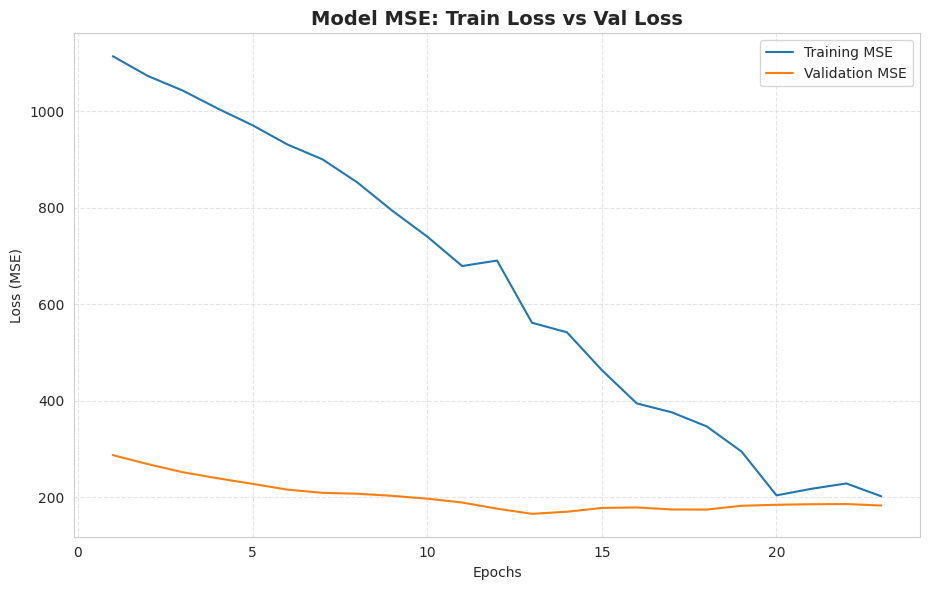

In [44]:
import matplotlib.pyplot as plt
import pickle
import os

history_data = {}
files = {
    'mse': '/kaggle/working/history_mse.pkl',
    'mae': '/kaggle/working/history_mae.pkl',
    'no_aug': '/kaggle/working/history_no_aug.pkl'
}

print("Đang tải dữ liệu...")
for name, filepath in files.items():
    if os.path.exists(filepath):
        with open(filepath, 'rb') as f:
            history_data[name] = pickle.load(f)
        print(f"Đã load: {filepath}")
    else:
        print(f"Không tìm thấy file {filepath} -> Dùng dữ liệu demo.")
        

def plot_loss_curves(history, title, metric_name='MSE'):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.plot(epochs, history['train_loss'], label=f'Training {metric_name}')
    plt.plot(epochs, history['val_loss'], label=f'Validation {metric_name}')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel(f'Loss ({metric_name})')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plot_loss_curves(history_data['mse'], 'Model MSE: Train Loss vs Val Loss', metric_name='MSE')

plt.tight_layout()
plt.show()

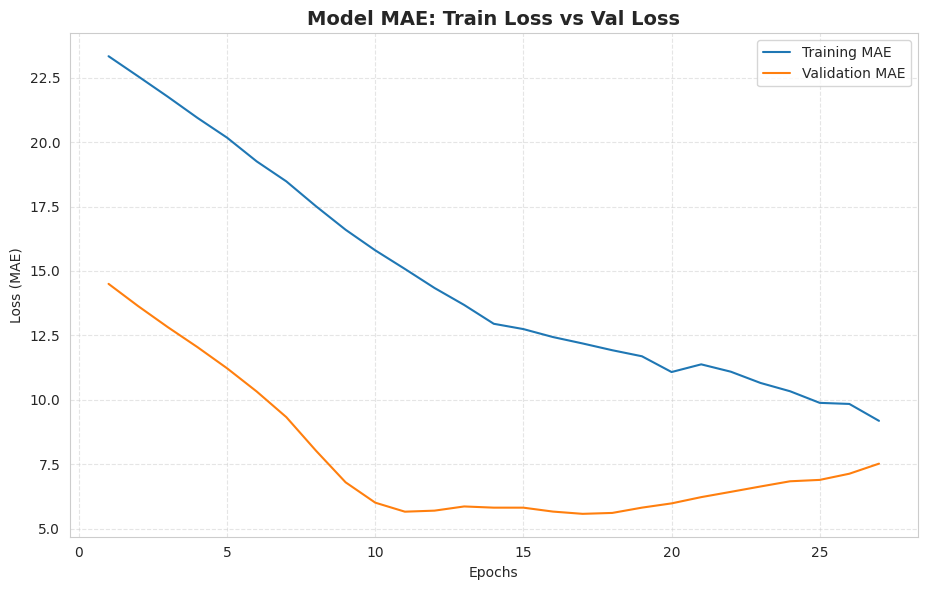

In [45]:
# Biểu đồ 2: Model dùng MAE (So sánh Train MAE vs Val MAE)
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 2)
plot_loss_curves(history_data['mae'], 'Model MAE: Train Loss vs Val Loss', metric_name='MAE')

plt.tight_layout()
plt.show()

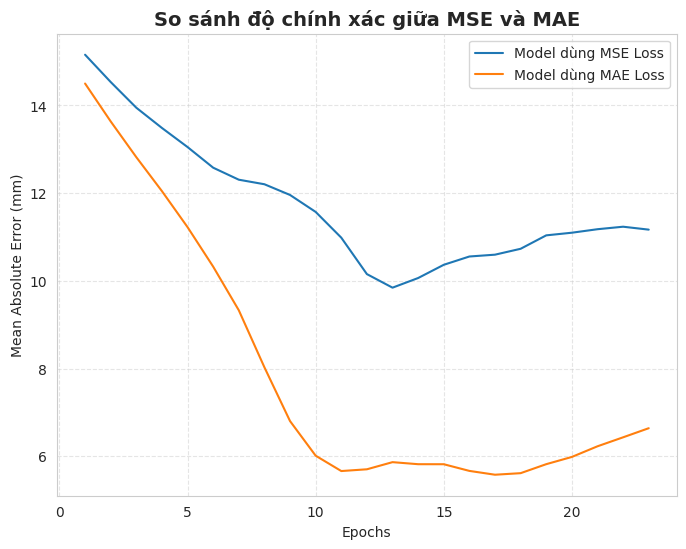

In [46]:
import matplotlib.pyplot as plt

def compare_mse_mae(history_mse, history_mae):
    # Lấy số epoch nhỏ hơn để tránh lệch chiều
    min_epochs = min(
        len(history_mse['val_mae']),
        len(history_mae['val_mae'])
    )
    
    epochs = range(1, min_epochs + 1)

    mse_val_mae = history_mse['val_mae'][:min_epochs]
    mae_val_mae = history_mae['val_mae'][:min_epochs]

    plt.figure(figsize=(8, 6))
    plt.plot(epochs, mse_val_mae, label='Model dùng MSE Loss')
    plt.plot(epochs, mae_val_mae, label='Model dùng MAE Loss')

    plt.title('So sánh độ chính xác giữa MSE và MAE', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Absolute Error (mm)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
compare_mse_mae(history_mse, history_mae)


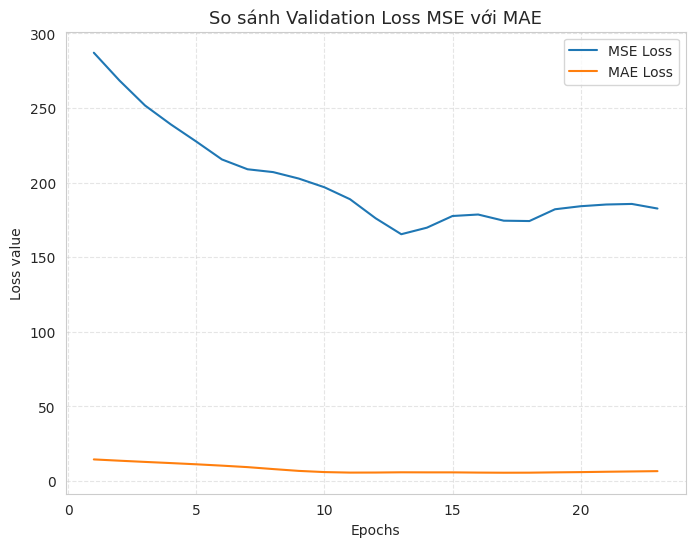

In [47]:
def compare_loss(history_mse, history_mae):
    min_epochs = min(
        len(history_mse['val_loss']),
        len(history_mae['val_loss'])
    )
    
    epochs = range(1, min_epochs + 1)

    plt.figure(figsize=(8, 6))
    plt.plot(epochs, history_mse['val_loss'][:min_epochs], label='MSE Loss')
    plt.plot(epochs, history_mae['val_loss'][:min_epochs], label='MAE Loss')

    plt.title('So sánh Validation Loss MSE với MAE', fontsize=13)
    plt.xlabel('Epochs')
    plt.ylabel('Loss value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
compare_loss(history_mse, history_mae)

Đã load model thành công!
Đang tính toán trên tập TRAIN...
Đang tính toán trên tập VALIDATION...
Đang tính toán trên tập TEST...

 BẢNG TỔNG HỢP KẾT QUẢ CÁC TẬP DỮ LIỆU
TẬP TRAIN:
   - RMSE: 22.77 mm
   - MAPE: 36.50 %
------------------------------
TẬP VALIDATION:
   - RMSE: 7.33 mm
   - MAPE: 37.01 %
------------------------------
TẬP TEST:
   - MSE:  268.12 (mm²)
   - RMSE: 16.37 mm
   - MAE:  10.00 mm
   - MAPE: 44.03 %
   - R2:   -0.2214


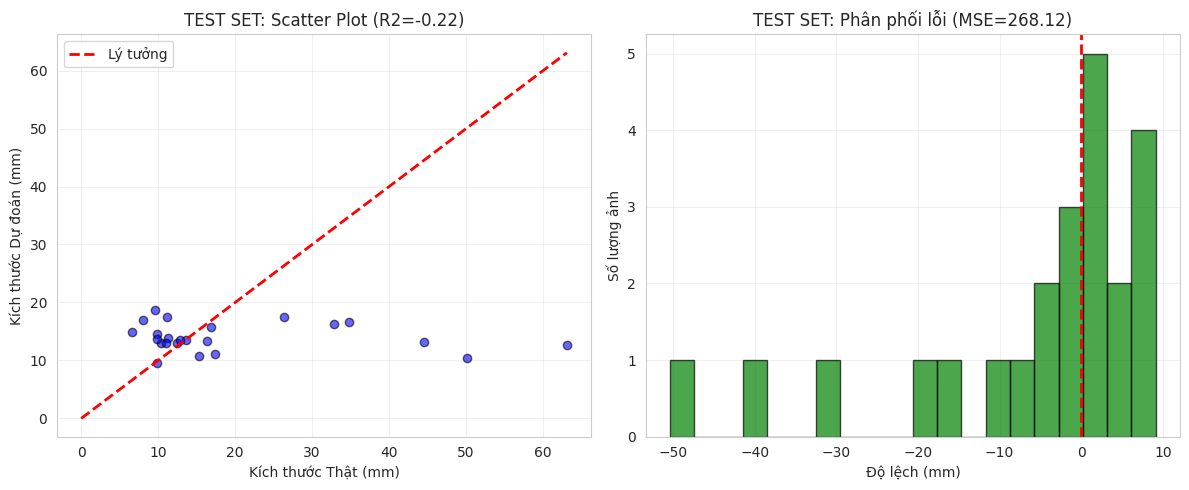

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import torch

def get_metrics(model, loader, device, set_name="Data"):
    model.eval()
    true_sizes = []
    pred_sizes = []
    
    print(f"Đang tính toán trên tập {set_name}...")
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            
            true_sizes.extend(labels.cpu().numpy().flatten())
            pred_sizes.extend(outputs.cpu().numpy().flatten())
            
    true_sizes = np.array(true_sizes)
    pred_sizes = np.array(pred_sizes)
    
    # Tính các chỉ số
    mse = mean_squared_error(true_sizes, pred_sizes)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true_sizes, pred_sizes)
    r2 = r2_score(true_sizes, pred_sizes)
    
    # Tính MAPE (MPAE)
    epsilon = 1e-7
    percentage_errors = np.abs((true_sizes - pred_sizes) / (true_sizes + epsilon)) * 100
    mape = np.mean(percentage_errors)
    
    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'r2': r2,
        'true': true_sizes,
        'pred': pred_sizes
    }

def evaluate_all_sets(model, train_loader, val_loader, test_loader, device):
    # 1. Tính toán cho từng tập
    train_metrics = get_metrics(model, train_loader, device, "TRAIN")
    val_metrics   = get_metrics(model, val_loader, device, "VALIDATION")
    test_metrics  = get_metrics(model, test_loader, device, "TEST")
    
    print("\n" + "="*50)
    print(" BẢNG TỔNG HỢP KẾT QUẢ CÁC TẬP DỮ LIỆU")
    print("="*50)
    
    
    print(f"TẬP TRAIN:")
    print(f"   - RMSE: {train_metrics['rmse']:.2f} mm")
    print(f"   - MAPE: {train_metrics['mape']:.2f} %")
    print("-" * 30)
    
    print(f"TẬP VALIDATION:")
    print(f"   - RMSE: {val_metrics['rmse']:.2f} mm")
    print(f"   - MAPE: {val_metrics['mape']:.2f} %")
    print("-" * 30)
    
    print(f"TẬP TEST:")
    print(f"   - MSE:  {test_metrics['mse']:.2f} (mm²)")
    print(f"   - RMSE: {test_metrics['rmse']:.2f} mm")
    print(f"   - MAE:  {test_metrics['mae']:.2f} mm")
    print(f"   - MAPE: {test_metrics['mape']:.2f} %")
    print(f"   - R2:   {test_metrics['r2']:.4f}")
    print("="*50)

    true_sizes = test_metrics['true']
    pred_sizes = test_metrics['pred']
    
    plt.figure(figsize=(12, 5))
    
    # Scatter Plot
    plt.subplot(1, 2, 1)
    plt.scatter(true_sizes, pred_sizes, alpha=0.6, color='blue', edgecolors='k')
    max_val = max(max(true_sizes), max(pred_sizes))
    plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Lý tưởng')
    plt.title(f'TEST SET: Scatter Plot (R2={test_metrics["r2"]:.2f})')
    plt.xlabel('Kích thước Thật (mm)')
    plt.ylabel('Kích thước Dự đoán (mm)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Histogram Error
    errors = pred_sizes - true_sizes
    plt.subplot(1, 2, 2)
    plt.hist(errors, bins=20, color='green', edgecolor='black', alpha=0.7)
    plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
    plt.title(f'TEST SET: Phân phối lỗi (MSE={test_metrics["mse"]:.2f})')
    plt.xlabel('Độ lệch (mm)')
    plt.ylabel('Số lượng ảnh')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


model_best = TumorSizeResNet18().to(device)
try:
    model_best.load_state_dict(torch.load('tumor_model_mae.pth', map_location=device))
    print("Đã load model thành công!")
except FileNotFoundError:
    print("Không tìm thấy file model!")

evaluate_all_sets(model_best, train_loader, val_loader, test_loader, device)

--- BẮT ĐẦU SO SÁNH HIỆU QUẢ CỦA LOSS FUNCTION ---
Đã load thành công: tumor_model_mae.pth
Đã load thành công: tumor_model_mse.pth

KẾT QUẢ SO SÁNH TRÊN TẬP TEST
1. Model train bằng MAE Loss -> Test MAE: 9.9999 mm
2. Model train bằng MSE Loss -> Test MAE: 14.8312 mm
--------------------------------------------------
KẾT LUẬN:MAE Loss tốt hơn!
   (Giúp giảm sai số thêm 4.8312 mm)


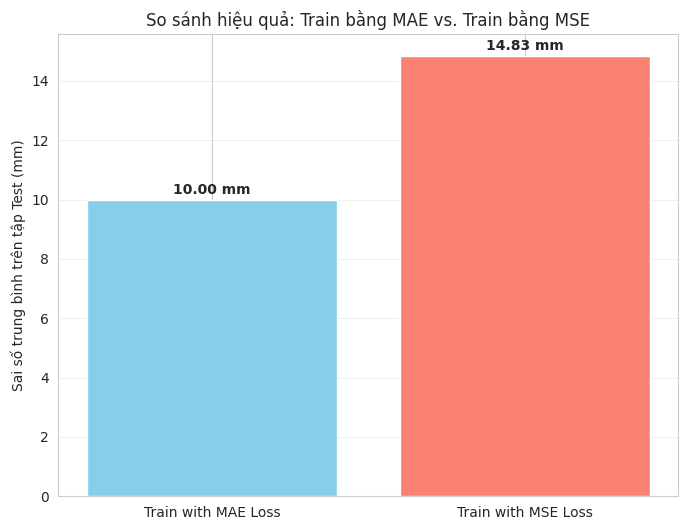

In [55]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

def get_test_mae(model_path, test_loader, device):
    """
    Load model từ đường dẫn và tính MAE trên tập Test
    """
    # Khởi tạo model
    model = TumorSizeResNet18().to(device)
    
    # Load trọng số (Weights)
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Đã load thành công: {model_path}")
    except FileNotFoundError:
        print(f"Không tìm thấy file: {model_path}")
        return None

    model.eval()
    true_sizes = []
    pred_sizes = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            
            true_sizes.extend(labels.cpu().numpy().flatten())
            pred_sizes.extend(outputs.cpu().numpy().flatten())
            
    # Tính MAE (Đơn vị: mm)
    mae_score = mean_absolute_error(true_sizes, pred_sizes)
    return mae_score


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("--- BẮT ĐẦU SO SÁNH HIỆU QUẢ CỦA LOSS FUNCTION ---")

path_mae_model = 'tumor_model_mae.pth'  
path_mse_model = 'tumor_model_mse.pth'  


mae_result_1 = get_test_mae(path_mae_model, test_loader, device)
mae_result_2 = get_test_mae(path_mse_model, test_loader, device)


print("\n" + "="*50)
print("KẾT QUẢ SO SÁNH TRÊN TẬP TEST")
print("="*50)

results = {}

if mae_result_1 is not None:
    print(f"1. Model train bằng MAE Loss -> Test MAE: {mae_result_1:.4f} mm")
    results['Train with MAE Loss'] = mae_result_1

if mae_result_2 is not None:
    print(f"2. Model train bằng MSE Loss -> Test MAE: {mae_result_2:.4f} mm")
    results['Train with MSE Loss'] = mae_result_2

if len(results) == 2:
    # So sánh
    diff = abs(mae_result_1 - mae_result_2)
    winner = "MAE Loss" if mae_result_1 < mae_result_2 else "MSE Loss"
    print("-" * 50)
    print(f"KẾT LUẬN:{winner} tốt hơn!")
    print(f"   (Giúp giảm sai số thêm {diff:.4f} mm)")
    
    # Vẽ biểu đồ cột so sánh
    plt.figure(figsize=(8, 6))
    bars = plt.bar(results.keys(), results.values(), color=['skyblue', 'salmon'])
    
    plt.ylabel('Sai số trung bình trên tập Test (mm)')
    plt.title('So sánh hiệu quả: Train bằng MAE vs. Train bằng MSE')
    plt.grid(axis='y', alpha=0.3)
    
    # Hiển thị số trên đầu cột
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f} mm', ha='center', va='bottom', fontweight='bold')
        
    plt.show()
else:
    print("\nKhông đủ 2 model để so sánh. Hãy chắc chắn bạn đã train đủ cả 2 trường hợp.")


Đang chạy cấu hình: No Aug (Baseline)...
   -> Kết quả: Test MAE = 7.91 mm

Đang chạy cấu hình: Horizontal Flip...
   -> Kết quả: Test MAE = 7.80 mm

Đang chạy cấu hình: Rotation + Flip...
   -> Kết quả: Test MAE = 7.47 mm

Đang chạy cấu hình: Brightness + Contrast...
   -> Kết quả: Test MAE = 7.85 mm

Đang chạy cấu hình: Full Augmentation...
   -> Kết quả: Test MAE = 8.31 mm

BẢNG KẾT QUẢ SO SÁNH AUGMENTATION
           Configuration  Test MAE (mm)  Improvement (%)
0      No Aug (Baseline)       7.908473         0.000000
1        Horizontal Flip       7.798888         1.385665
2        Rotation + Flip       7.472333         5.514853
3  Brightness + Contrast       7.848331         0.760476
4      Full Augmentation       8.311963        -5.101991


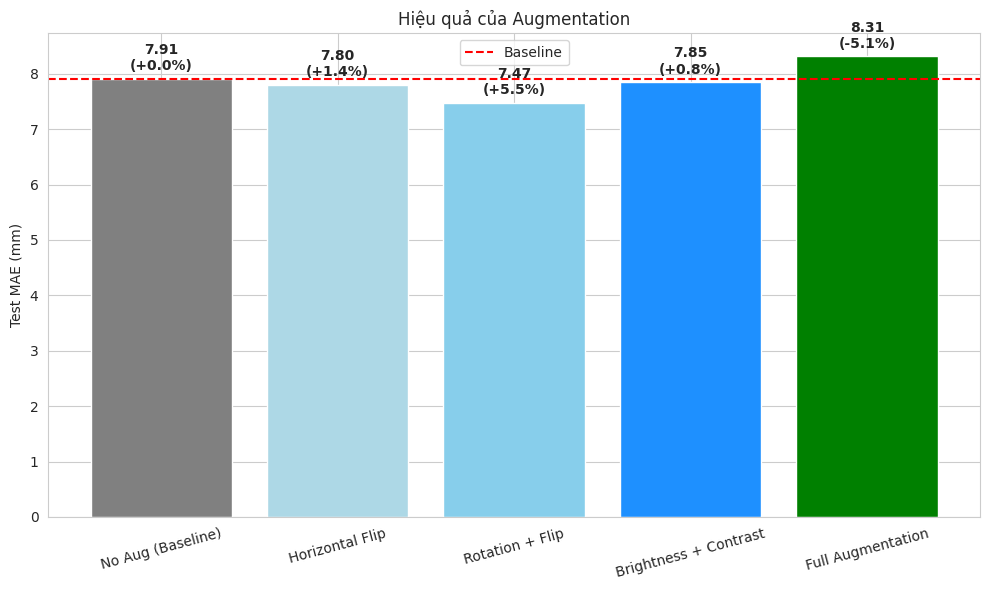

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ĐỊNH NGHĨA LẠI TRANSFORM
def get_transforms_custom(config_name):
    step_resize = transforms.Resize((224, 224))
    step_tensor = transforms.ToTensor()
    step_norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    
    aug_flip = transforms.RandomHorizontalFlip(p=0.5)
    aug_rotate = transforms.RandomRotation(degrees=15)
    aug_affine = transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)) # Thay cho Zoom
    aug_color = transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)
    aug_blur = transforms.GaussianBlur(kernel_size=(3, 5), sigma=(0.1, 2.0))
    
    # Xây dựng danh sách transform dựa trên tên cấu hình
    if config_name == "No Aug (Baseline)":
        # Chỉ Resize -> Tensor -> Norm
        return transforms.Compose([step_resize, step_tensor, step_norm])
        
    elif config_name == "Horizontal Flip":
        return transforms.Compose([step_resize, aug_flip, step_tensor, step_norm])
        
    elif config_name == "Rotation + Flip":
        return transforms.Compose([step_resize, aug_flip, aug_rotate, step_tensor, step_norm])
        
    elif config_name == "Brightness + Contrast":
        return transforms.Compose([step_resize, aug_color, step_tensor, step_norm])
        
    elif config_name == "Full Augmentation":
        return transforms.Compose([
            step_resize,
            aug_flip,
            aug_rotate,
            aug_affine, # Dịch chuyển
            aug_color,
            aug_blur,   # Gaussian Blur
            step_tensor,
            step_norm
        ])
    
    return None

def run_experiment(config_name, train_df, val_df, test_df, device):
    print(f"\nĐang chạy cấu hình: {config_name}...")
    
    # a. Load Dataset với Transform tương ứng
    train_transform = get_transforms_custom(config_name)
    val_test_transform = get_transforms_custom("No Aug (Baseline)") 
    
    train_ds = ChestXrayDataset(train_df, train_transform)
    val_ds = ChestXrayDataset(val_df, val_test_transform)
    test_ds = ChestXrayDataset(test_df, val_test_transform)
    
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=16)
    test_loader = DataLoader(test_ds, batch_size=16)
    
    # Khởi tạo Model & Optimizer
    model = TumorSizeResNet18().to(device)
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3) # Cấu hình tối ưu cũ

    epochs = 15 
    best_val_mae = float('inf')
    
    for epoch in range(epochs):
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls.float().unsqueeze(1))
            loss.backward()
            optimizer.step()
            
        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs = model(imgs)
                val_losses.append(criterion(outputs, lbls.float().unsqueeze(1)).item())
        
        avg_val_mae = np.mean(val_losses)
        if avg_val_mae < best_val_mae:
            best_val_mae = avg_val_mae
            torch.save(model.state_dict(), 'temp_best_ablation.pth')
            
    # d. Test Evaluation
    model.load_state_dict(torch.load('temp_best_ablation.pth', map_location=device))
    model.eval()
    test_losses = []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            test_losses.append(criterion(outputs, lbls.float().unsqueeze(1)).item())
            
    test_mae = np.mean(test_losses)
    print(f"   -> Kết quả: Test MAE = {test_mae:.2f} mm")
    return best_val_mae, test_mae

# CHẠY VÒNG LẶP CHÍNH
configs = [
    "No Aug (Baseline)",
    "Horizontal Flip",
    "Rotation + Flip",
    "Brightness + Contrast",
    "Full Augmentation"
]

results = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for cfg in configs:
    val_mae, test_mae = run_experiment(cfg, train_df, val_df, test_df, device)
    results.append({
        "Configuration": cfg,
        "Test MAE (mm)": test_mae
    })


res_df = pd.DataFrame(results)
baseline_mae = res_df.loc[res_df['Configuration'] == "No Aug (Baseline)", 'Test MAE (mm)'].values[0]
res_df['Improvement (%)'] = ((baseline_mae - res_df['Test MAE (mm)']) / baseline_mae) * 100

print("\n" + "="*60)
print("BẢNG KẾT QUẢ SO SÁNH AUGMENTATION")
print("="*60)
print(res_df)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bars = plt.bar(res_df['Configuration'], res_df['Test MAE (mm)'], color=['gray', 'lightblue', 'skyblue', 'dodgerblue', 'green'])
plt.axhline(y=baseline_mae, color='red', linestyle='--', label='Baseline')

plt.title('Hiệu quả của Augmentation')
plt.ylabel('Test MAE (mm)')
plt.xticks(rotation=15)
plt.legend()

for bar, imp in zip(bars, res_df['Improvement (%)']):
    yval = bar.get_height()
    label = f"{yval:.2f}\n({imp:+.1f}%)"
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, label, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Đang xử lý ảnh: 00022837_005.png


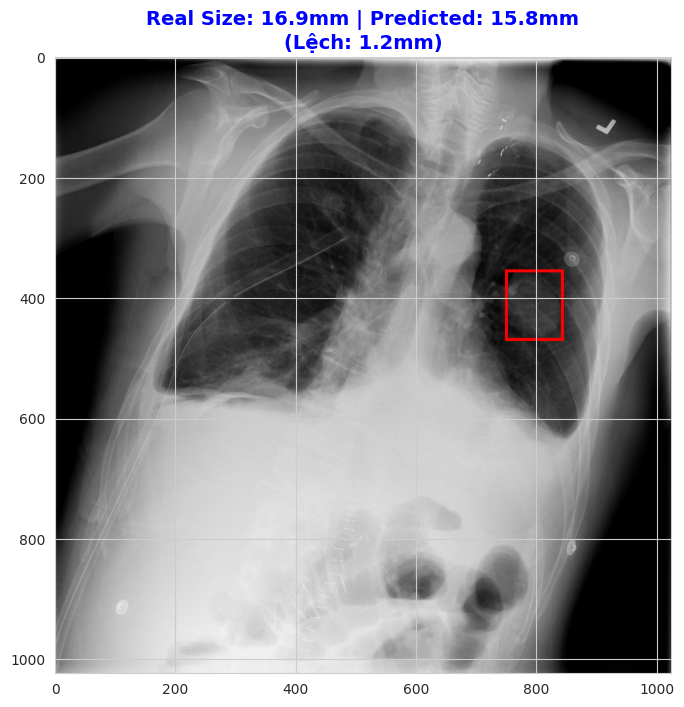

In [79]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import numpy as np

# --- 1. KHAI BÁO LẠI KIẾN TRÚC MODEL (Phải giống hệt lúc train) ---
class TumorSizeResNet18(nn.Module):
    def __init__(self):
        super(TumorSizeResNet18, self).__init__()
        
        # Dùng ResNet18 thay vì ResNet50 (nhẹ hơn, phù hợp dữ liệu ít)
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Bỏ 2 lớp cuối (AvgPool và FC)
        self.features = nn.Sequential(*list(backbone.children())[:-2])
        
        # 1. Freeze các lớp đầu (học đường nét cơ bản)
        for param in self.features.parameters():
            param.requires_grad = False
            
        # 2. Unfreeze Layer 4 (để học đặc trưng khối u)
        # Truy cập vào block layer4 của ResNet
        for param in self.features[7].parameters(): # layer4 nằm ở index 7 trong sequential
            param.requires_grad = True
            
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Regression Head
        # ResNet18 output 512 channels
        self.regression_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_avg_pool(x)
        output = self.regression_head(x)
        return output

def predict_and_visualize(image_info_row, model_path, device):
    """
    image_info_row: Một dòng pandas Series chứa đường dẫn ảnh và tọa độ bbox thật.
    """
    image_path = image_info_row['path']
    real_size_mm = image_info_row['Tumor_Size_mm']
    
    # a. Load Model
    model = TumorSizeResNet18().to(device)
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file model '{model_path}'.")
        return

    # b. Xử lý ảnh để đưa vào model
    transform_for_model = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    try:
        img_pil = Image.open(image_path).convert('RGB')
        # Tạo bản sao để vẽ bbox lên (không resize cái này để giữ nguyên tọa độ gốc)
        img_to_draw = img_pil.copy()
        
        # Transform để đưa vào model dự đoán
        img_tensor = transform_for_model(img_pil).unsqueeze(0).to(device)
    except Exception as e:
        print(f"Lỗi đọc ảnh: {e}")
        return

    # c. Dự đoán kích thước
    with torch.no_grad():
        output = model(img_tensor)
        predicted_size_mm = output.item()

    # d. Vẽ Bounding Box Thật lên ảnh gốc
    # Lấy tọa độ từ dòng thông tin (cần chuyển sang int)
    try:
        x = int(image_info_row['x'])
        y = int(image_info_row['y'])
        w = int(image_info_row['w'])
        h = int(image_info_row['h'])
        
        draw = ImageDraw.Draw(img_to_draw)
        # Vẽ hình chữ nhật: [x0, y0, x1, y1], màu đỏ, độ dày 5
        draw.rectangle([x, y, x + w, y + h], outline="red", width=5)
    except Exception as e:
        print(f"Không thể vẽ bbox (có thể do thiếu dữ liệu tọa độ): {e}")

    # e. Hiển thị kết quả
    plt.figure(figsize=(8, 8))
    plt.imshow(img_to_draw)
    
    plt.axis('on') 
    
    # Tiêu đề so sánh
    title_text = f"Real Size: {real_size_mm:.1f}mm | Predicted: {predicted_size_mm:.1f}mm\n(Lệch: {abs(real_size_mm - predicted_size_mm):.1f}mm)"
    plt.title(title_text, color='blue', fontsize=14, fontweight='bold')
    
    plt.show()
    
    return predicted_size_mm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_FILE = 'tumor_model_mae.pth' 

if os.path.exists('test.csv') and os.path.exists(MODEL_FILE):
    test_df = pd.read_csv('test.csv')
    
    random_row = test_df.sample(1).iloc[0]
    
    print(f"Đang xử lý ảnh: {os.path.basename(random_row['path'])}")

    predict_and_visualize(random_row, MODEL_FILE, device)
    
else:
    print("Lỗi: Không tìm thấy file 'test.csv' hoặc file model (.pth).")

In [78]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image, ImageStat
from sklearn.metrics import confusion_matrix, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import os

def get_image_stats(img_path):
    """Tính độ tương phản (Contrast) dựa trên độ lệch chuẩn pixel"""
    try:
        img = Image.open(img_path).convert('L')
        stat = ImageStat.Stat(img)
        return stat.stddev[0]
    except:
        return 0

def analyze_report_data(model_path, csv_path, device):
    
    # Load Data
    df = pd.read_csv(csv_path)
    model = TumorSizeResNet18().to(device)
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
    except:
        print(" Không tìm thấy file model. Đang dùng model khởi tạo ngẫu nhiên để demo code.")
    
    model.eval()
    
    # Transform
    transform = transforms.Compose([
        transforms.Resize((224, 224)), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    results = []
    
    with torch.no_grad():
        for idx, row in df.iterrows():
            img_path = row['path']
            real_size = row['Tumor_Size_mm']
            
            try:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)
                pred_size = model(input_tensor).item()
                
                # Tính độ tương phản
                contrast = get_image_stats(img_path)
                
                results.append({
                    'real': real_size,
                    'pred': pred_size,
                    'error': abs(real_size - pred_size),
                    'diff': pred_size - real_size, # Dương là Over, Âm là Under
                    'contrast': contrast
                })
            except:
                pass

    res_df = pd.DataFrame(results)
    print("CÁC YẾU TỐ ẢNH HƯỞNG ĐẾN HIỆU SUẤT")
    print("="*40)
    ranges = [
        ('< 10mm', lambda x: x < 10),
        ('10-20mm', lambda x: (x >= 10) & (x < 20)),
        ('20-30mm', lambda x: (x >= 20) & (x < 30)),
        ('30-50mm', lambda x: (x >= 30) & (x < 50)),
        ('> 50mm', lambda x: x >= 50)
    ]
    
    for name, condition in ranges:
        subset = res_df[condition(res_df['real'])]
        mae = subset['error'].mean() if len(subset) > 0 else 0
        count = len(subset)
        print(f"● Range {name} (SL: {count} ảnh):")
        print(f"   Mean Absolute Error: {mae:.2f} mm")
        
    print("="*40)
    threshold = 5.0
    
    over = res_df[res_df['diff'] > threshold]
    under = res_df[res_df['diff'] < -threshold]
    total = len(res_df)
    
    print("1. Overestimation (Dự đoán > Thực tế):")
    print(f"   - Số lượng: {len(over)} ({len(over)/total*100:.1f}%)")
    print(f"   - Error trung bình: {over['error'].mean():.2f} mm")
    
    print("2. Underestimation (Dự đoán < Thực tế):")
    print(f"   - Số lượng: {len(under)} ({len(under)/total*100:.1f}%)")
    print(f"   - Error trung bình: {under['error'].mean():.2f} mm")

    # --- PHẦN 6.1.3: CONFUSION MATRIX ---
    print("\n" + "="*40)
    print("📝 DỮ LIỆU CHO MỤC 6.1.3 (Confusion Matrix)")
    print("="*40)
    
    def categorize(size):
        if size < 20: return 'Small'
        elif size < 40: return 'Medium'
        else: return 'Large'
        
    y_true_cat = res_df['real'].apply(categorize)
    y_pred_cat = res_df['pred'].apply(categorize)
    labels = ['Small', 'Medium', 'Large']
    
    cm = confusion_matrix(y_true_cat, y_pred_cat, labels=labels)
    
    print("Confusion Matrix (Hàng: True, Cột: Pred):")
    print(f"{'':<10} {'Small':<10} {'Medium':<10} {'Large':<10}")
    for i, row in enumerate(cm):
        print(f"{labels[i]:<10} {row[0]:<10} {row[1]:<10} {row[2]:<10}")

    print("="*40)
    # Chia contrast thành High/Low dựa trên Median
    median_contrast = res_df['contrast'].median()
    low_contrast = res_df[res_df['contrast'] <= median_contrast]
    high_contrast = res_df[res_df['contrast'] > median_contrast]
    
    print(f"Median Contrast Threshold: {median_contrast:.2f}")
    print(f"● Ảnh tương phản thấp -> MAE: {low_contrast['error'].mean():.2f} mm")
    print(f"● Ảnh tương phản cao  -> MAE: {high_contrast['error'].mean():.2f} mm")
    
    impact = ((low_contrast['error'].mean() - high_contrast['error'].mean()) / high_contrast['error'].mean()) * 100
    print(f"● Impact: Tương phản thấp làm tăng error {impact:.1f}%")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
analyze_report_data('tumor_model_mae.pth', 'test.csv', device)

CÁC YẾU TỐ ẢNH HƯỞNG ĐẾN HIỆU SUẤT
● Range < 10mm (SL: 6 ảnh):
   Mean Absolute Error: 5.87 mm
● Range 10-20mm (SL: 11 ảnh):
   Mean Absolute Error: 2.73 mm
● Range 20-30mm (SL: 1 ảnh):
   Mean Absolute Error: 8.89 mm
● Range 30-50mm (SL: 3 ảnh):
   Mean Absolute Error: 21.97 mm
● Range > 50mm (SL: 2 ảnh):
   Mean Absolute Error: 44.99 mm
1. Overestimation (Dự đoán > Thực tế):
   - Số lượng: 4 (17.4%)
   - Error trung bình: 8.21 mm
2. Underestimation (Dự đoán < Thực tế):
   - Số lượng: 7 (30.4%)
   - Error trung bình: 24.43 mm

📝 DỮ LIỆU CHO MỤC 6.1.3 (Confusion Matrix)
Confusion Matrix (Hàng: True, Cột: Pred):
           Small      Medium     Large     
Small      17         0          0         
Medium     3          0          0         
Large      3          0          0         
Median Contrast Threshold: 63.24
● Ảnh tương phản thấp -> MAE: 13.88 mm
● Ảnh tương phản cao  -> MAE: 5.77 mm
● Impact: Tương phản thấp làm tăng error 140.5%
